## Data Setup & Cleaning

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:\\Users\\Dell\\Downloads\\Sample.csv")

In [3]:
df.head()

,MODEL,MAKE,MODEL.1,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,Unnamed: 9,Unnamed: 10,Unnamed: 11,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,7.2,8.3,34,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,7.4,8.3,34,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,8.8,11.5,25,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,8.8,11.6,24,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,10.9,13.1,22,301


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MODEL              679 non-null    int64  
 1   MAKE               679 non-null    object 
 2   MODEL.1            679 non-null    object 
 3   VEHICLE CLASS      679 non-null    object 
 4   ENGINE_SIZE        679 non-null    float64
 5   CYLINDERS          679 non-null    int64  
 6   TRANSMISSION       679 non-null    object 
 7   FUEL               679 non-null    object 
 8   FUEL_CONSUMPTION*  679 non-null    float64
 9   Unnamed: 9         679 non-null    float64
 10  Unnamed: 10        679 non-null    float64
 11  Unnamed: 11        679 non-null    int64  
 12  CO2_EMISSIONS      679 non-null    int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 69.1+ KB


In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [6]:
df.head()

,MODEL,MAKE,MODEL.1,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301


In [7]:
df = df.drop_duplicates()

df = df.dropna()

In [8]:
selected_cols = [
    'VEHICLE CLASS', 'FUEL', 'TRANSMISSION',
    'ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*', 'CO2_EMISSIONS'
]
df_ml = df[selected_cols]  # for ML only!


## Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Info:\n", df.info())
print("Describe:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MODEL              679 non-null    int64  
 1   MAKE               679 non-null    object 
 2   MODEL.1            679 non-null    object 
 3   VEHICLE CLASS      679 non-null    object 
 4   ENGINE_SIZE        679 non-null    float64
 5   CYLINDERS          679 non-null    int64  
 6   TRANSMISSION       679 non-null    object 
 7   FUEL               679 non-null    object 
 8   FUEL_CONSUMPTION*  679 non-null    float64
 9   CO2_EMISSIONS      679 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 53.2+ KB
Info:
 None
Describe:
         MODEL  ENGINE_SIZE   CYLINDERS  FUEL_CONSUMPTION*  CO2_EMISSIONS
count   679.0   679.000000  679.000000         679.000000     679.000000
mean   2001.0     3.252577    5.798233          14.591900     293.656848
std       0.0 

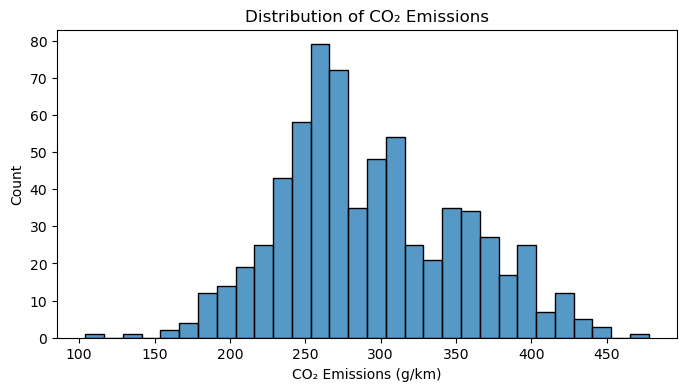

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['CO2_EMISSIONS'], bins=30)
plt.xlabel('CO₂ Emissions (g/km)')
plt.title('Distribution of CO₂ Emissions')
plt.show()

## Feature Engineering and Encoding

In [11]:
# Define input features and target
X_raw = df_ml.drop('CO2_EMISSIONS', axis=1)
y = df_ml['CO2_EMISSIONS']

In [12]:
X = pd.get_dummies(X_raw, columns=['VEHICLE CLASS', 'FUEL', 'TRANSMISSION'], drop_first=True)

## Train/Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building & Evaluation

### Linear Regression

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression MAE: 4.0473935850274145
Linear Regression RMSE: 5.4119936056577265
Linear Regression R²: 0.9914320084958919


### RandomForestRegressor

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 3.7373989845938373
Random Forest RMSE: 6.687382622766158
Random Forest R²: 0.986917919347987


### KNeighborsRegressor

In [17]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)
print("KNN MAE:", mae_knn)
print("KNN RMSE:", rmse_knn)
print("KNN R²:", r2_knn)

KNN MAE: 6.382352941176469
KNN RMSE: 8.930318484538729
KNN R²: 0.9766708791613132


### DecisionTreeRegressor

In [18]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree MAE:", mae_dt)
print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R²:", r2_dt)

Decision Tree MAE: 4.408088235294118
Decision Tree RMSE: 7.710644857445262
Decision Tree R²: 0.982608146093205


### AdaBooster 

In [19]:
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, AdaBoostRegressor, GradientBoostingRegressor, BaggingRegressor

ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, y_pred_ada))
r2_ada = r2_score(y_test, y_pred_ada)
print("AdaBoost MAE:", mae_ada)
print("AdaBoost RMSE:", rmse_ada)
print("AdaBoost R²:", r2_ada)


AdaBoost MAE: 8.743507492334953
AdaBoost RMSE: 10.519852721967064
AdaBoost R²: 0.9676269366551582


### GradientBoostingRegressor

In [19]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R²:", r2_gb)


Gradient Boosting MAE: 3.9001628002299724
Gradient Boosting RMSE: 5.029107607788888
Gradient Boosting R²: 0.9926014547518529


###  BaggingRegressor

In [20]:
bag = BaggingRegressor(random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
mae_bag = mean_absolute_error(y_test, y_pred_bag)
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))
r2_bag = r2_score(y_test, y_pred_bag)
print("Bagging MAE:", mae_bag)
print("Bagging RMSE:", rmse_bag)
print("Bagging R²:", r2_bag)


Bagging MAE: 3.55593137254902
Bagging RMSE: 5.647776284590627
Bagging R²: 0.9906691878013515


### Best Regression Model

### Results Table

In [21]:
results = {
    "Model": [
        "Linear Regression", "Random Forest", "KNN",
        "Decision Tree", "AdaBoost", "GradientBoosting", "Bagging"
    ],
    "MAE": [
        mae_lr, mae_rf, mae_knn,
        mae_dt, mae_ada, mae_gb, mae_bag
    ],
    "RMSE": [
        rmse_lr, rmse_rf, rmse_knn,
        rmse_dt, rmse_ada, rmse_gb, rmse_bag
    ],
    "R2": [
        r2_lr, r2_rf, r2_knn,
        r2_dt, r2_ada, r2_gb, r2_bag
    ]
}

results_df = pd.DataFrame(results)
print(results_df)


               Model       MAE       RMSE        R2
0  Linear Regression  4.047394   5.411994  0.991432
1      Random Forest  3.737399   6.687383  0.986918
2                KNN  6.382353   8.930318  0.976671
3      Decision Tree  4.408088   7.710645  0.982608
4           AdaBoost  8.743507  10.519853  0.967627
5   GradientBoosting  3.900163   5.029108  0.992601
6            Bagging  3.555931   5.647776  0.990669


In [22]:
best_model_index = results_df['RMSE'].idxmin()
best_model_row = results_df.loc[best_model_index]
print("Best Regression Model Results (Lowest RMSE):")
print(best_model_row)

Best Regression Model Results (Lowest RMSE):
Model    GradientBoosting
MAE              3.900163
RMSE             5.029108
R2               0.992601
Name: 5, dtype: object


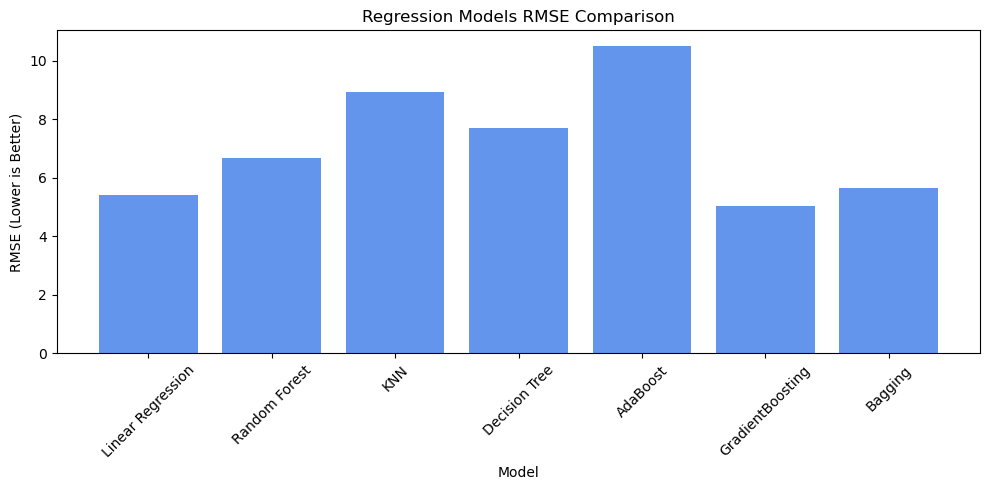

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['RMSE'], color='cornflowerblue')
plt.xlabel("Model")
plt.ylabel("RMSE (Lower is Better)")
plt.title("Regression Models RMSE Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Gradient Boosting Pipeline

In [25]:
from sklearn.model_selection import train_test_split

# Columns in your df_ml (from earlier work)[attached_file:101]
feature_cols = ['VEHICLE CLASS', 'FUEL', 'TRANSMISSION',
                'ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*']
target_col = 'CO2_EMISSIONS'

X = df_ml[feature_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['VEHICLE CLASS', 'FUEL', 'TRANSMISSION']
numeric_features     = ['ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', GradientBoostingRegressor(random_state=42))
])


In [26]:
gb_pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = gb_pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Gradient Boosting Pipeline MAE :", mae)
print("Gradient Boosting Pipeline RMSE:", rmse)
print("Gradient Boosting Pipeline R²  :", r2)


Gradient Boosting Pipeline MAE : 3.9005183732677486
Gradient Boosting Pipeline RMSE: 5.029111630006376
Gradient Boosting Pipeline R²  : 0.9926014429173199


In [28]:
print("First 10 true CO₂ values:", y_test.head(10).values)
print("First 10 predicted CO₂ values:", y_pred[:10])

First 10 true CO₂ values: [237 260 308 359 391 294 354 265 202 370]
First 10 predicted CO₂ values: [240.97580179 261.62961701 302.35168181 356.06283879 390.7686224
 296.04653483 349.31984339 267.38741635 194.90307243 376.92140543]


### Actual vs Predicted CO₂ Emissions

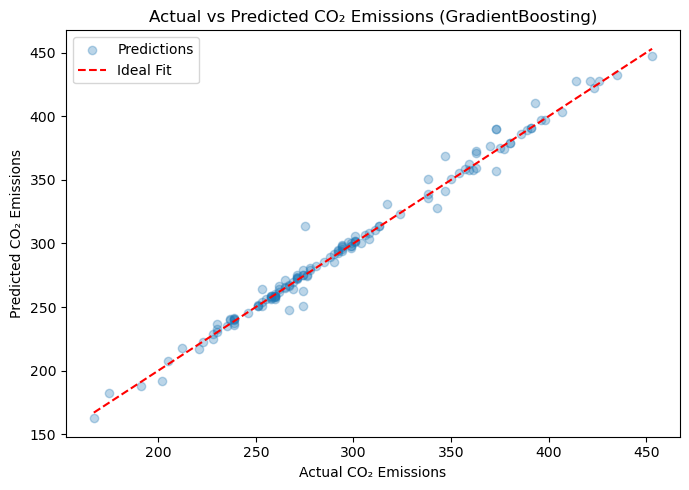

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title(f"Actual vs Predicted CO₂ Emissions ({best_model_row['Model']})")
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
# quantiles of CO2_EMISSIONS
q1 = df['CO2_EMISSIONS'].quantile(0.33)
q2 = df['CO2_EMISSIONS'].quantile(0.66)

print(q1, q2)


260.0 311.0


In [34]:
bins = [df['CO2_EMISSIONS'].min()-1, q1, q2, df['CO2_EMISSIONS'].max()+1]
labels = ['Low', 'Medium', 'High']

df['Emission_Band'] = pd.cut(df['CO2_EMISSIONS'], bins=bins, labels=labels)
df['Emission_Band'].value_counts()


Emission_Band
Low       228
High      226
Medium    225
Name: count, dtype: int64

In [35]:
df_encoded = pd.get_dummies(df,
                            columns=['VEHICLE CLASS', 'FUEL', 'TRANSMISSION'],
                            drop_first=True)

X_class = df_encoded.drop(['CO2_EMISSIONS', 'Emission_Band'], axis=1)
y_class = df_encoded['Emission_Band']


In [42]:
# Start from df that already has CO2_EMISSIONS and Emission_Band

# One‑hot encode the main categorical features you care about
df_encoded = pd.get_dummies(
    df,
    columns=['VEHICLE CLASS', 'FUEL', 'TRANSMISSION'],
    drop_first=True
)

# Drop target + band + text/id columns that are not useful for prediction
X_class = df_encoded.drop(
    ['CO2_EMISSIONS', 'Emission_Band', 'MAKE', 'MODEL', 'MODEL.1'],
    axis=1
)
y_class = df_encoded['Emission_Band']

print(X_class.dtypes.head())   # now all should be int64/float64


ENGINE_SIZE                float64
CYLINDERS                    int64
FUEL_CONSUMPTION*          float64
VEHICLE CLASS_FULL-SIZE       bool
VEHICLE CLASS_MID-SIZE        bool
dtype: object


### Classification Models

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

log_clf = LogisticRegression(max_iter=1000, multi_class='auto')
log_clf.fit(X_train_c, y_train_c)

y_pred_log = log_clf.predict(X_test_c)
print("Logistic Regression accuracy:", accuracy_score(y_test_c, y_pred_log))
print(classification_report(y_test_c, y_pred_log))


C:\Users\Dell\anaconda3\envs\co2env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression accuracy: 0.9117647058823529
              precision    recall  f1-score   support

        High       0.95      0.98      0.96        41
         Low       0.95      0.83      0.89        42
      Medium       0.86      0.92      0.89        53

    accuracy                           0.91       136
   macro avg       0.92      0.91      0.91       136
weighted avg       0.91      0.91      0.91       136



In [44]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_c, y_train_c)

y_pred_dt = dt_clf.predict(X_test_c)
print("Decision Tree accuracy:", accuracy_score(y_test_c, y_pred_dt))
print(classification_report(y_test_c, y_pred_dt))


Decision Tree accuracy: 0.9485294117647058
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        41
         Low       0.93      0.95      0.94        42
      Medium       0.94      0.92      0.93        53

    accuracy                           0.95       136
   macro avg       0.95      0.95      0.95       136
weighted avg       0.95      0.95      0.95       136



In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)

y_pred_rf = rf_clf.predict(X_test_c)
print("Random Forest accuracy:", accuracy_score(y_test_c, y_pred_rf))
print(classification_report(y_test_c, y_pred_rf))


Random Forest accuracy: 0.9632352941176471
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        41
         Low       0.95      0.95      0.95        42
      Medium       0.94      0.96      0.95        53

    accuracy                           0.96       136
   macro avg       0.97      0.96      0.96       136
weighted avg       0.96      0.96      0.96       136



In [46]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train_c, y_train_c)

y_pred_svm = svm_clf.predict(X_test_c)
print("SVM (RBF) accuracy:", accuracy_score(y_test_c, y_pred_svm))
print(classification_report(y_test_c, y_pred_svm))


SVM (RBF) accuracy: 0.8970588235294118
              precision    recall  f1-score   support

        High       0.97      0.95      0.96        41
         Low       0.94      0.79      0.86        42
      Medium       0.82      0.94      0.88        53

    accuracy                           0.90       136
   macro avg       0.91      0.89      0.90       136
weighted avg       0.90      0.90      0.90       136



In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_c, y_train_c)

y_pred_knn = knn_clf.predict(X_test_c)
print("KNN (k=5) accuracy:", accuracy_score(y_test_c, y_pred_knn))
print(classification_report(y_test_c, y_pred_knn))


KNN (k=5) accuracy: 0.9117647058823529
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        41
         Low       0.88      0.88      0.88        42
      Medium       0.89      0.89      0.89        53

    accuracy                           0.91       136
   macro avg       0.91      0.91      0.91       136
weighted avg       0.91      0.91      0.91       136



### Best Classification Model

In [53]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='auto'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, clf in models.items():
    clf.fit(X_train_c, y_train_c)
    y_pred = clf.predict(X_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    results[name] = acc
    print(f"{name} accuracy: {acc:.4f}")

best_model_name = max(results, key=results.get)
print("\nBest model:", best_model_name, "with accuracy:", results[best_model_name])


C:\Users\Dell\anaconda3\envs\co2env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression accuracy: 0.9118
Decision Tree accuracy: 0.9485
Random Forest accuracy: 0.9632
SVM (RBF) accuracy: 0.8971
KNN (k=5) accuracy: 0.9118

Best model: Random Forest with accuracy: 0.9632352941176471


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Start from original df (before get_dummies)
feature_cols = ['VEHICLE CLASS', 'FUEL', 'TRANSMISSION',
                'ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*']
target_col = 'Emission_Band'

X_full = df[feature_cols]
y_full = df[target_col]

cat_cols = ['VEHICLE CLASS', 'FUEL', 'TRANSMISSION']
num_cols = ['ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*']

preprocess_clf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_clf),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_full, y_full)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
df['Predicted_Band'] = rf_pipeline.predict(X_full)
df[['CO2_EMISSIONS', 'Emission_Band', 'Predicted_Band']].head(700)


,CO2_EMISSIONS,Emission_Band,Predicted_Band
0,191,Low,Low
1,191,Low,Low
2,265,Medium,Medium
3,267,Medium,Medium
4,301,Medium,Medium
...,...,...,...
674,260,Low,Low
675,258,Low,Low
676,253,Low,Low
677,288,Medium,Medium


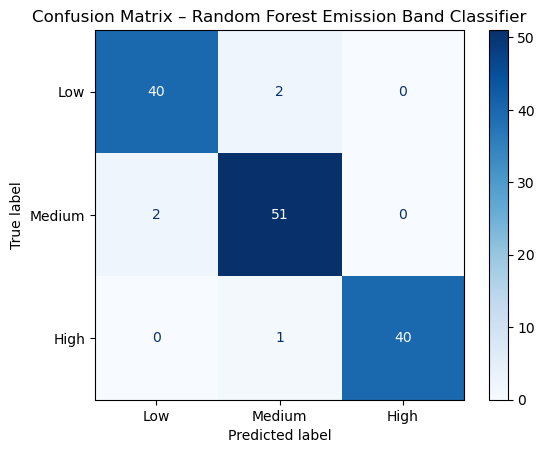

In [142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Get predictions on the classification test set
y_pred_class = rf_clf.predict(X_test_c)

# 2) Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_class, labels=['Low', 'Medium', 'High'])

# 3) Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Random Forest Emission Band Classifier")
plt.show()


### Prediction

In [1]:
import pandas as pd

def predict_co2_and_band_pipeline(car_dict, reg_pipeline, clf_pipeline):
    """
    car_dict: dict with raw car features (same column names as in df)
    reg_pipeline: trained pipeline for CO2 regression (e.g., gb_pipeline)
    clf_pipeline: trained pipeline for band classification (e.g., rf_pipeline)
    """
    car_df = pd.DataFrame([car_dict])

    # 1) CO2 prediction with regression pipeline
    co2_pred = float(reg_pipeline.predict(car_df)[0])

    # 2) Band prediction (Low / Medium / High) with classifier pipeline
    band_pred = clf_pipeline.predict(car_df)[0]

    return co2_pred, band_pred


### Prediction For A New Car

In [64]:
new_car = {
    'VEHICLE CLASS': 'COMPACT',
    'FUEL': 'X',
    'TRANSMISSION': 'A4',
    'ENGINE_SIZE': 1.8,
    'CYLINDERS': 4,
    'FUEL_CONSUMPTION*': 7.5
}

pred_co2_new, pred_band_new = predict_co2_and_band_pipeline(
    car_dict=new_car,
    reg_pipeline=gb_pipeline,   # your Gradient Boosting pipeline
    clf_pipeline=rf_pipeline    # your Random Forest classifier pipeline
)

print("New car features:", new_car)
print("Predicted CO₂:", pred_co2_new)
print("Predicted band:", pred_band_new)


New car features: {'VEHICLE CLASS': 'COMPACT', 'FUEL': 'X', 'TRANSMISSION': 'A4', 'ENGINE_SIZE': 1.8, 'CYLINDERS': 4, 'FUEL_CONSUMPTION*': 7.5}
Predicted CO₂: 163.28197163071636
Predicted band: Low


### Prediction For A Existing Car

In [57]:
import pandas as pd

# 1) pick an existing car by index
idx = 0   # change to any valid index in df
feature_cols = ['VEHICLE CLASS', 'FUEL', 'TRANSMISSION',
                'ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*']

existing_car_df = df.loc[[idx], feature_cols]

# 2) predict CO2 using regression pipeline
pred_co2_exist = gb_pipeline.predict(existing_car_df)[0]

# 3) predict band using classifier pipeline
pred_band_exist = rf_pipeline.predict(existing_car_df)[0]

# 4) show true vs predicted
true_co2  = df.loc[idx, 'CO2_EMISSIONS']
true_band = df.loc[idx, 'Emission_Band']

print("Existing car index:", idx)
print("True CO₂:", true_co2, "| True band:", true_band)
print("Predicted CO₂:", pred_co2_exist)
print("Predicted band:", pred_band_exist)


Existing car index: 0
True CO₂: 191 | True band: Low
Predicted CO₂: 189.79561943498504
Predicted band: Low


                                  feature  importance
26                      FUEL_CONSUMPTION*    0.965238
24                            ENGINE_SIZE    0.007685
13                                 FUEL_E    0.007086
14                                 FUEL_N    0.005833
15                                 FUEL_X    0.004324
25                              CYLINDERS    0.003007
9                       VEHICLE CLASS_SUV    0.002722
5   VEHICLE CLASS_PICKUP TRUCK - STANDARD    0.001671
4      VEHICLE CLASS_PICKUP TRUCK - SMALL    0.000753
0                 VEHICLE CLASS_FULL-SIZE    0.000676


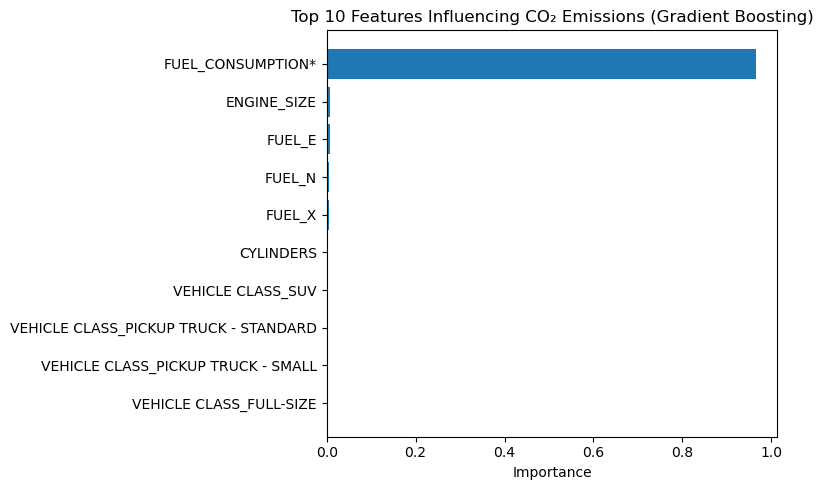

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Get feature names from the preprocessing step
preprocess = gb_pipeline.named_steps['preprocess']
cat_cols = ['VEHICLE CLASS', 'FUEL', 'TRANSMISSION']
num_cols = ['ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*']

ohe = preprocess.named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = cat_feature_names + num_cols

# 2) Get feature importances from Gradient Boosting
gb_model = gb_pipeline.named_steps['model']
importances = gb_model.feature_importances_

# 3) Put into a DataFrame and sort
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(fi_df.head(10))

# 4) Plot top features
plt.figure(figsize=(8,5))
plt.barh(fi_df['feature'][:10][::-1], fi_df['importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features Influencing CO₂ Emissions (Gradient Boosting)')
plt.tight_layout()
plt.show()
